In [1]:
import sys
sys.path.insert(0, '..')
import importlib

# Import from the package
from src import simulate, plot
from src.food import TRE
from src.params import num

%load_ext autoreload                             
%autoreload 2

In [2]:
res = simulate.run(food_fn=lambda t: TRE(t, num(2.1)))

In [13]:
print(vars(res)["S"])

[-60.         -59.99431218 -59.98876409 ... -59.61617391 -59.61617764
 -59.61618138]


720.0


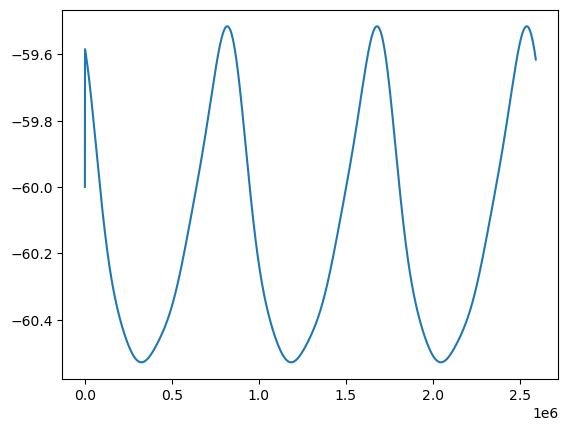

In [19]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks

plt.plot(vars(res)["S"])
print(len(vars(res)["S"]))

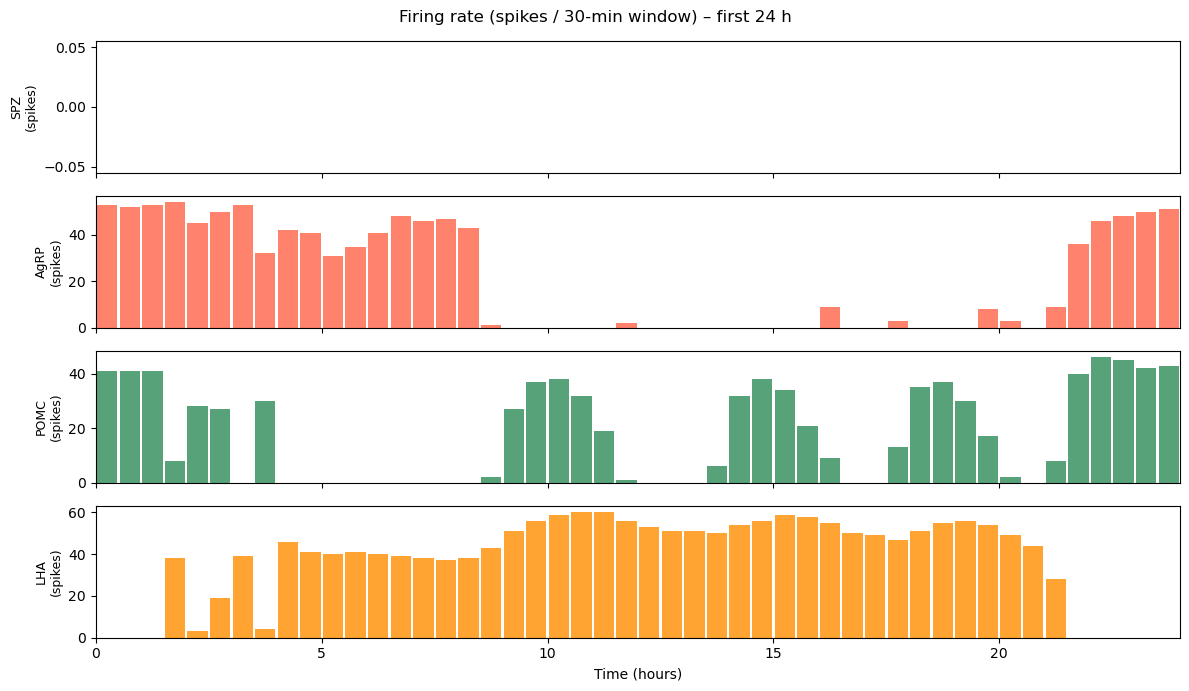

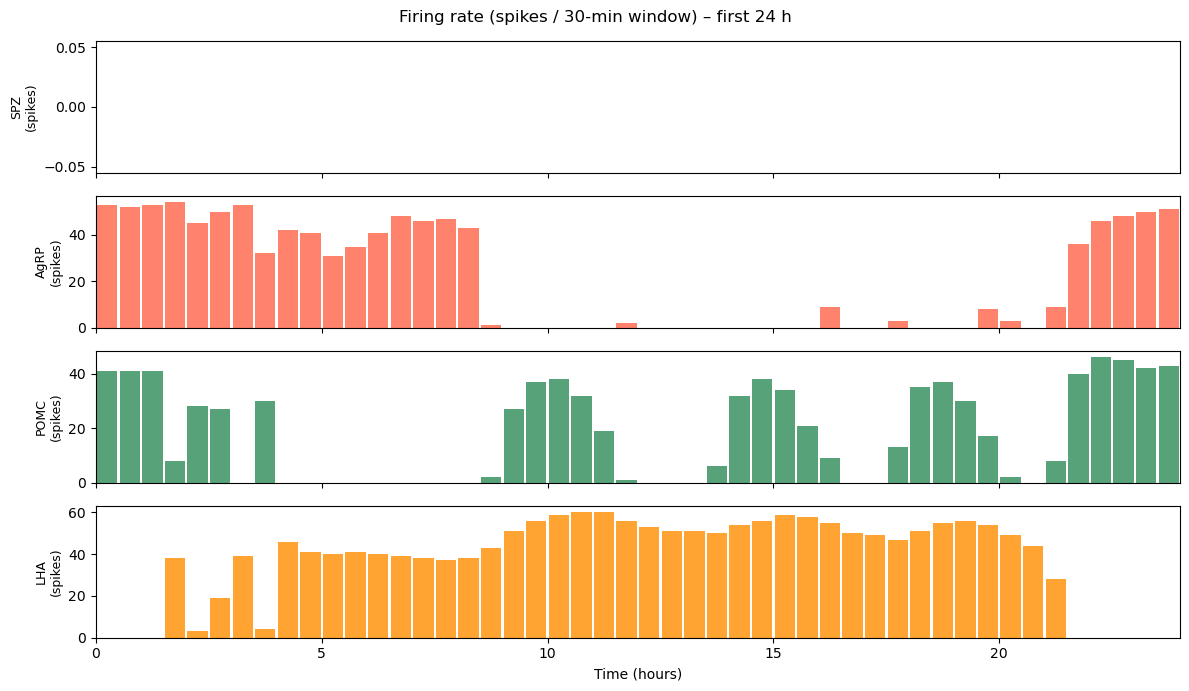

In [15]:

import matplotlib.pyplot as plt

import numpy as np
from scipy.signal import find_peaks
def plot_spike_counts(
    res,
    window_h: float = 0.5,
    hours: float = 24.0,
    peak_height: float = 0.0,
    peak_distance: int = 10,
) -> plt.Figure:
    edges   = np.arange(0.0, hours + window_h, window_h)
    centers = (edges[:-1] + edges[1:]) / 2

    def _count(voltage):
        counts = []
        for i in range(len(edges) - 1):
            t0 = edges[i]     * 3600.0
            t1 = edges[i + 1] * 3600.0
            seg = voltage[(res.t_s >= t0) & (res.t_s < t1)]
            if len(seg):
                pks, _ = find_peaks(seg, height=peak_height, distance=peak_distance)
                counts.append(len(pks))
            else:
                counts.append(0)
        return counts

    specs = [
        (_count(vars(res)["S"]), "SPZ",  "steelblue"),
        (_count(res.A), "AgRP", "tomato"),
        (_count(res.P), "POMC", "seagreen"),
        (_count(res.L), "LHA",  "darkorange"),
    ]

    fig, axes = plt.subplots(4, 1, figsize=(12, 7), sharex=True)
    fig.suptitle(f"Firing rate (spikes / {window_h*60:.0f}-min window) – first {hours:.0f} h",
                 fontsize=12)

    for ax, (counts, label, color) in zip(axes, specs):
        ax.bar(centers, counts, width=window_h * 0.9, color=color, alpha=0.8)
        ax.set_ylabel(f"{label}\n(spikes)", fontsize=9)

    axes[-1].set_xlabel("Time (hours)")
    axes[-1].set_xlim(0, hours)
    plt.tight_layout()
    return fig

plot_spike_counts(res)

Simulation summary
  Plasma glucose GL2 (mmol/L)         min=    0.00  mean=    0.19  max=    0.76
  Insulin IN (pM)                     min=   79.00  mean=  191.61  max=  459.86
  Ghrelin H1 (pg/mL)                  min=  369.72  mean=  550.46  max=  674.53
  Leptin LP (ng/mL)                   min=   15.91  mean=   20.06  max=   22.48
  α-MSH (nM)                          min=    0.00  mean=    0.02  max=    0.05
  AgRP (×1e-8 M)                      min=    0.00  mean=    0.02  max=    0.08
  MC4R activation                     min=    1.23  mean=    1.41  max=    1.58
Saved figures/neuron_voltages_24h.png
Saved figures/hormones_72h.png
Saved figures/neuropeptides_72h.png
Saved figures/synaptic_orexin_72h.png
Saved figures/spike_counts_24h.png
Saved figures/inputs_24h.png


[<Figure size 1400x800 with 4 Axes>,
 <Figure size 1400x900 with 4 Axes>,
 <Figure size 1400x700 with 3 Axes>,
 <Figure size 1400x900 with 4 Axes>,
 <Figure size 1200x700 with 4 Axes>,
 <Figure size 1200x500 with 2 Axes>]

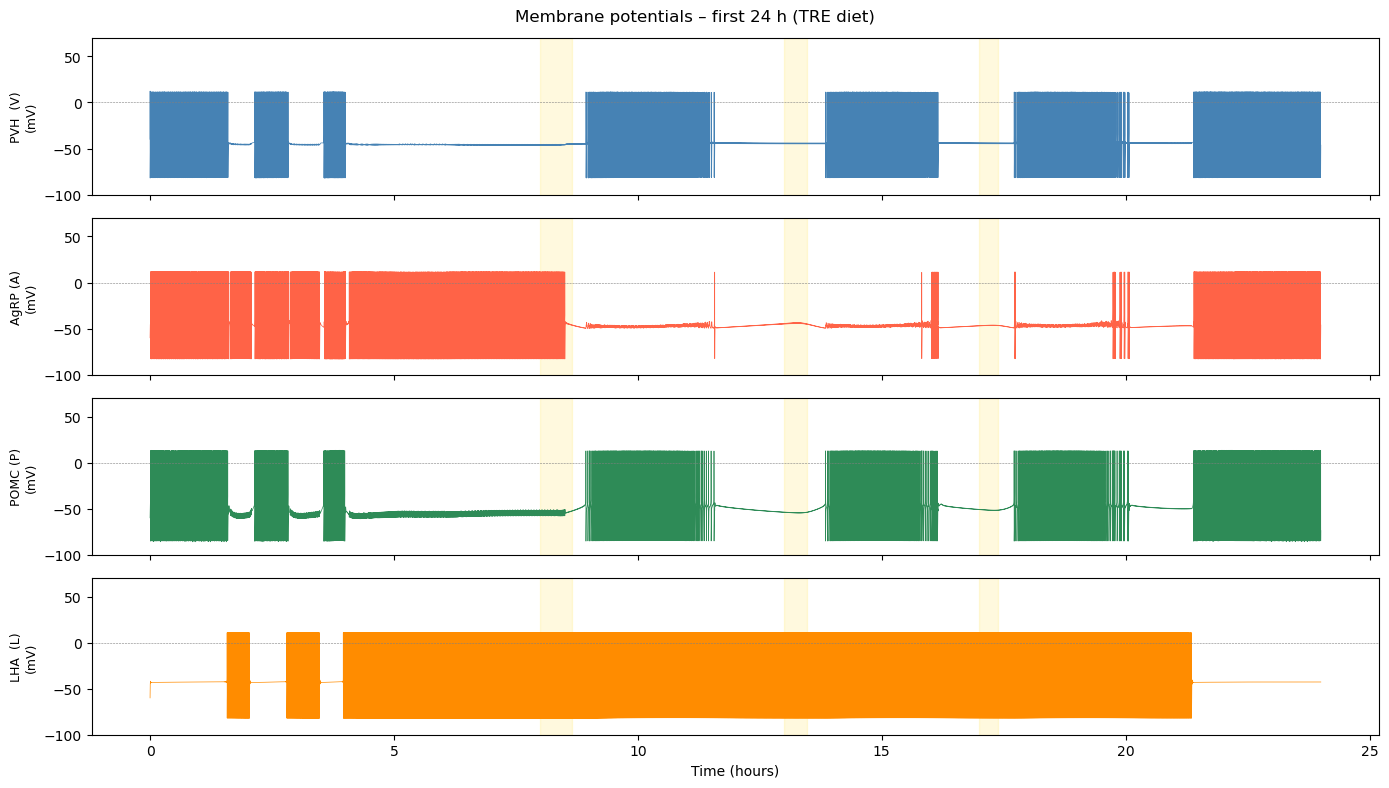

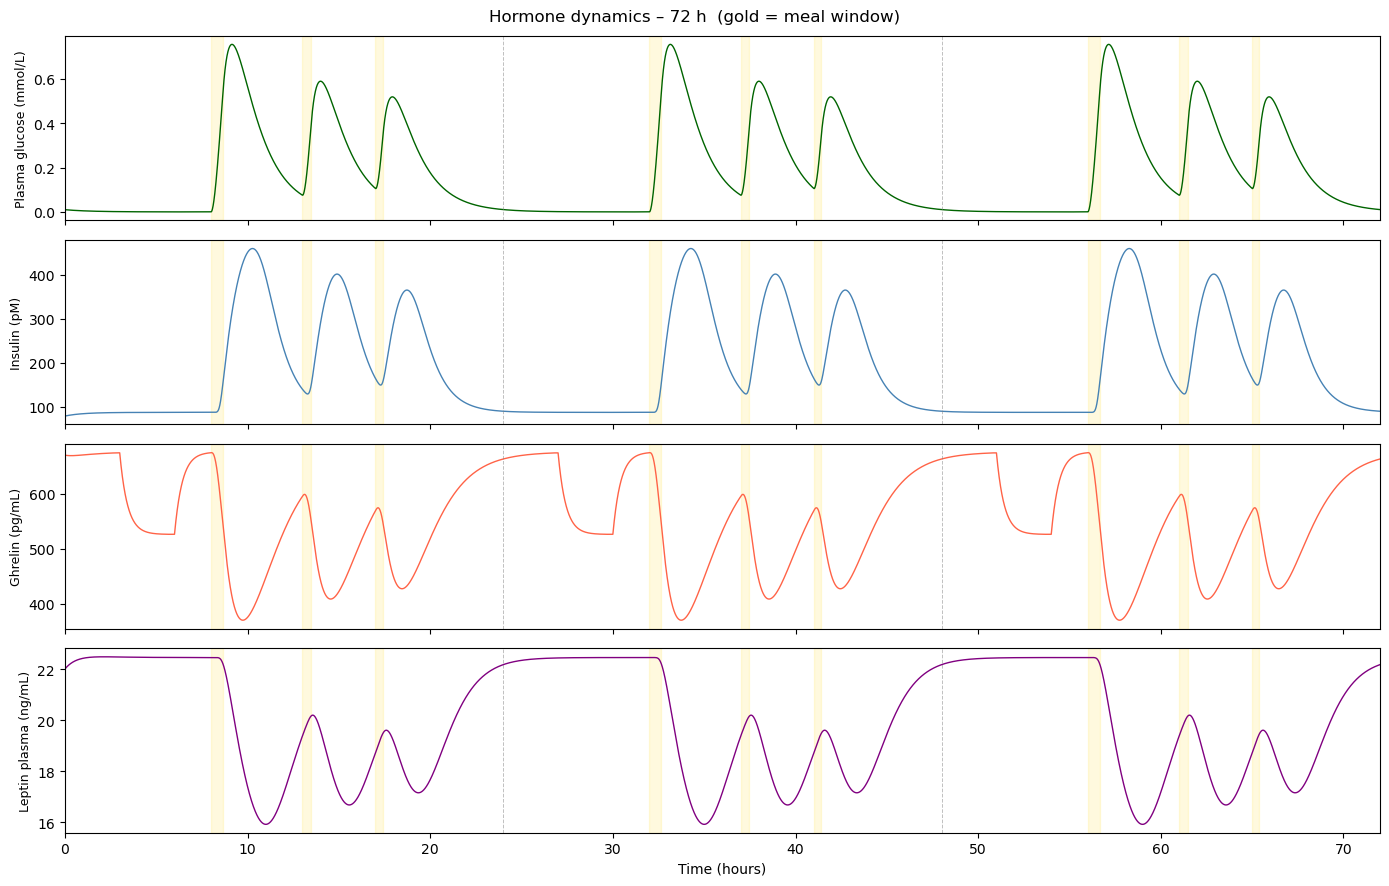

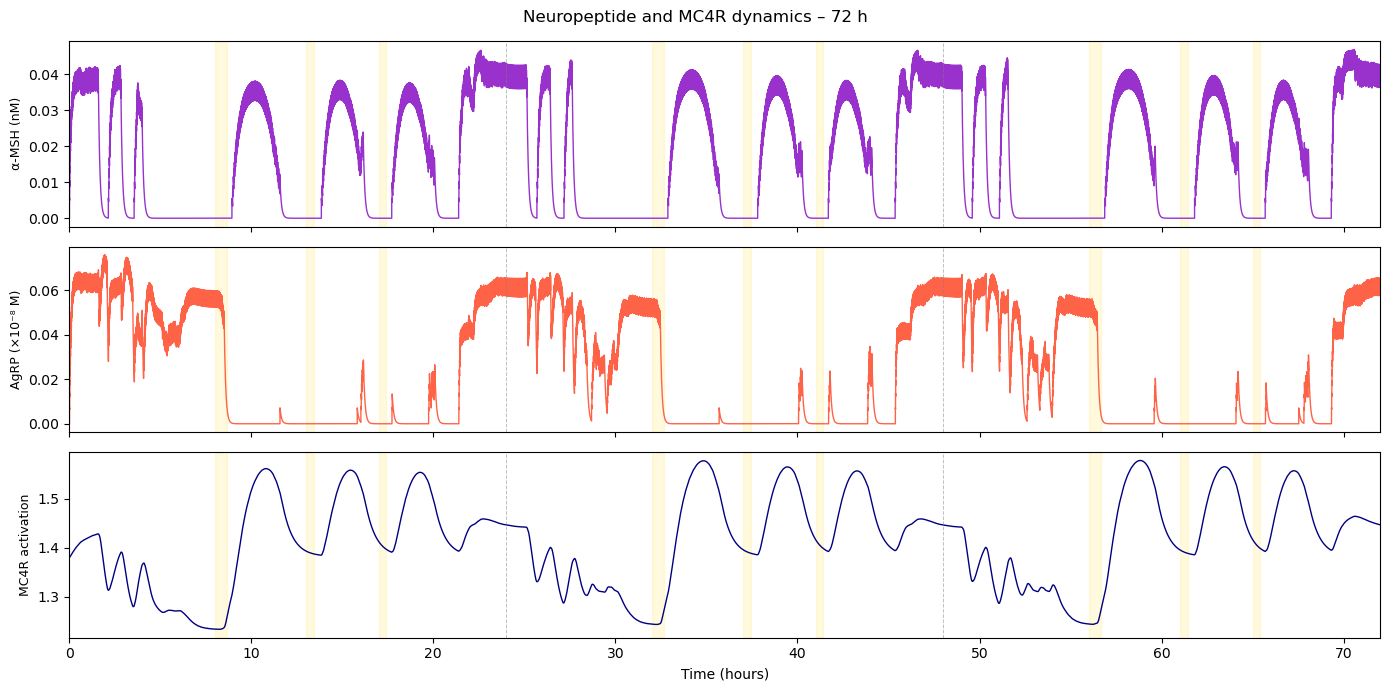

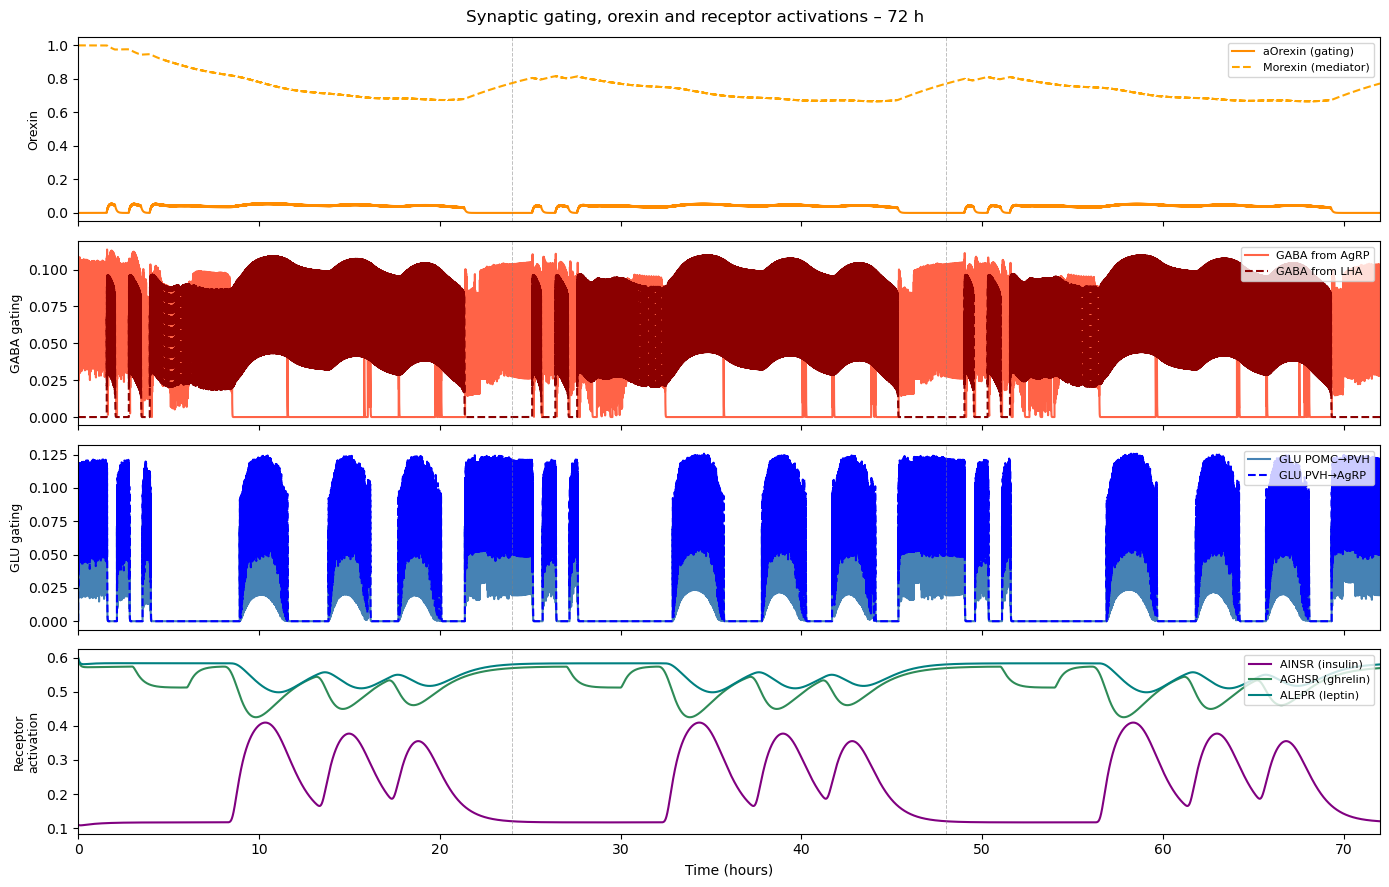

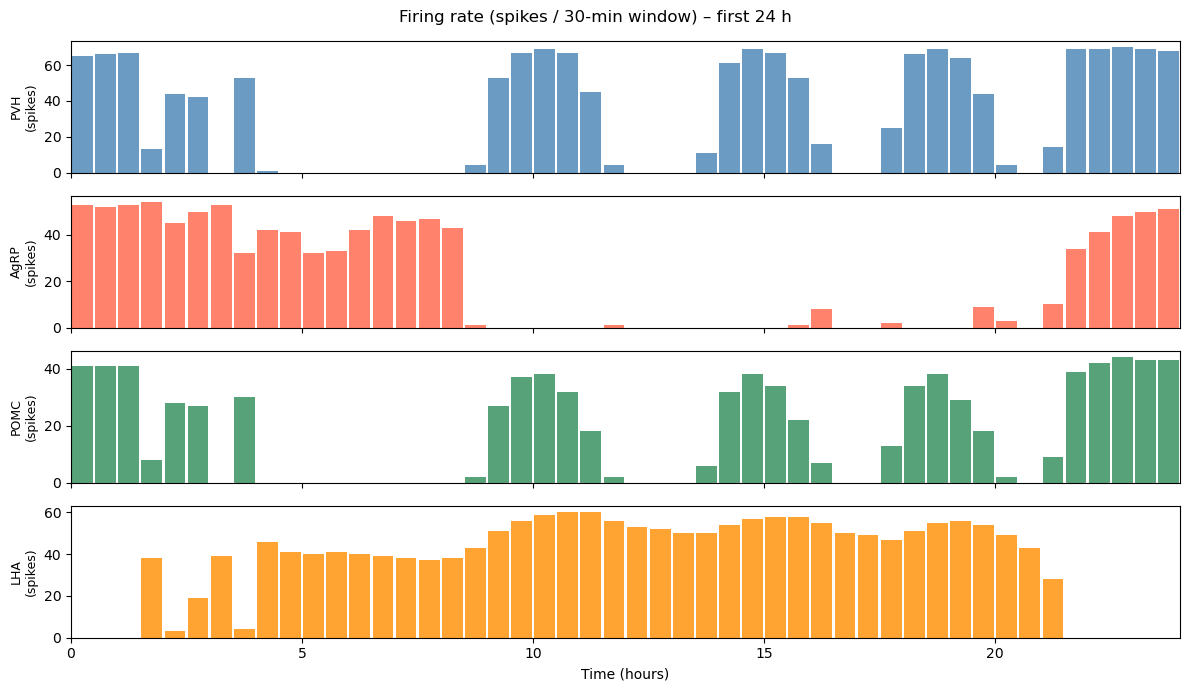

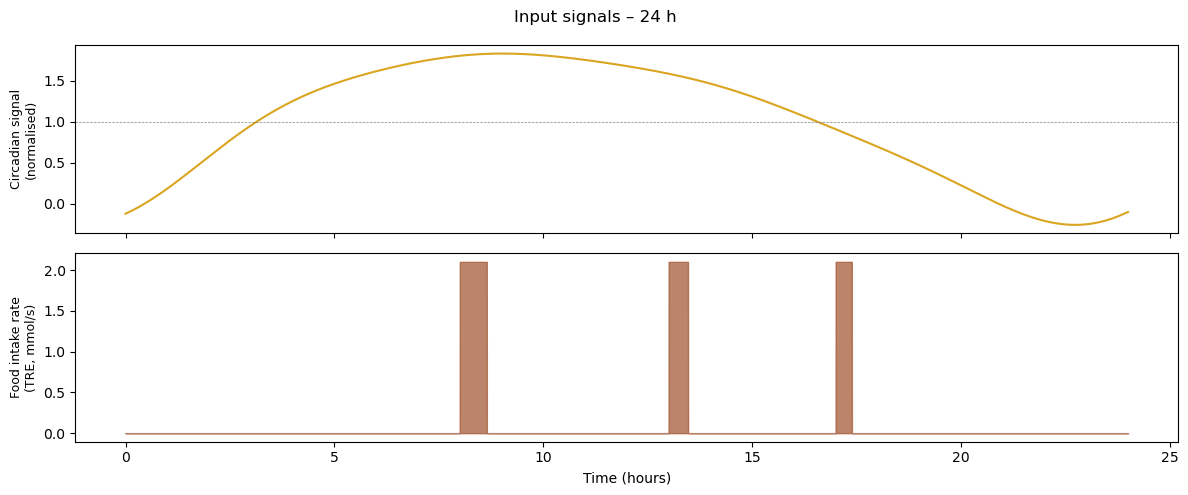

In [10]:
print(res.summary())
plot.plot_all(res, save_dir="figures")